# Integrating Data: No Formula Required

**This notebook is self-contained; it recaps Riemann sums before applying them to data.**

§3.8-1 integrated a function we had a formula for, which meant we could evaluate it anywhere and use as
many rectangles as we liked. Measured data does not work that way: you get the values you sampled and
nothing in between.

This is the same situation §3.4 faced for derivatives, and the resolution is the same, the Riemann
rules only ever needed **values**, not a formula. What changes is that the sampling interval is now
fixed for you.

## Learning objectives

- Apply the left, right, midpoint, and trapezoid rules to **sampled data**.
- Explain why the sample spacing sets a floor on accuracy.
- Interpret an integral of measured data as **area under the curve (AUC)**.

## Background

Given $n$ samples $(x_i, y_i)$ with spacing $\Delta x$, the rules from §3.8-1 apply directly:

$$\text{left} = \sum_{i} y_i\,\Delta x, \qquad
  \text{trapezoid} = \sum_{i} \frac{y_i + y_{i+1}}{2}\,\Delta x$$

The **midpoint** rule is the awkward one here: it needs the value *between* two samples, which we do
not have. Either interpolate, or use trapezoid instead, which is why trapezoid is the practical
default for data. NumPy provides it as `np.trapz`.

**Why this matters, AUC.** In pharmacokinetics, a blood-concentration curve $C(t)$ measured at
intervals has an area $\int C\,dt$ called the **AUC**, representing total drug exposure. The same
calculation gives total energy from a power reading, total distance from a speed reading, or total
rainfall from a rate gauge. Any time you have a **rate** and want a **total**, you are integrating.

## This notebook covers

1. Sampled data, with no underlying formula.
2. The rules applied to samples.
3. What the sample spacing costs.
4. AUC: a drug-concentration example.

**Prerequisites:** `U3-8_Integrals-1_RiemannSums`

**Dataset:** synthetic samples, plus a simulated concentration curve.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Data, not a formula

Here are eleven measurements. Pretend the underlying process is unknown, all you have is the dots.
The area under them still has meaning, and the rectangles from §3.8-1 still work.

In [2]:
x_data = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
y_data = np.array([2.0, 3.1, 4.4, 5.2, 5.6, 5.4, 4.7, 3.6, 2.6, 1.9, 1.5])
dx = x_data[1] - x_data[0]

print(f"{len(x_data)} samples, spacing dx = {dx}")
pd.DataFrame({'x': x_data, 'y': y_data}).T

11 samples, spacing dx = 0.5


,0,1,2,3,4,5,6,7,8,9,10
x,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
y,2.0,3.1,4.4,5.2,5.6,5.4,4.7,3.6,2.6,1.9,1.5


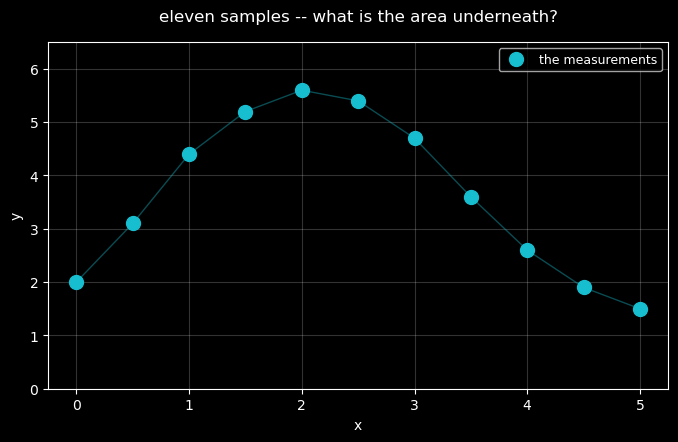

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_data, y_data, "o", color="tab:cyan", markersize=10, label="the measurements")
ax.plot(x_data, y_data, "-", color="tab:cyan", lw=1, alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_ylim(0, 6.5)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title("eleven samples -- what is the area underneath?", pad=15)
plt.show()

## 2. The rules, applied to samples

Left and right use the sample at one end of each gap; trapezoid averages both, slanting the top of
each strip to join the two points. Compare the pictures, the trapezoid version visibly hugs the data.

In [4]:
# note: np.trapz works on NumPy 1.x. It was renamed np.trapezoid in NumPy 2.0,
# so on a newer NumPy swap the name (the arguments are unchanged).
left = np.sum(y_data[:-1]) * dx
right = np.sum(y_data[1:]) * dx
trapz = np.trapz(y_data, x_data)

print(f"left rule      {left:9.4f}")
print(f"right rule     {right:9.4f}")
print(f"trapezoid      {trapz:9.4f}   = the average of left and right: {(left+right)/2:.4f}")
print(f"\nnp.trapz gives {np.trapz(y_data, x_data):.4f}")

left rule        19.2500
right rule       19.0000
trapezoid        19.1250   = the average of left and right: 19.1250

np.trapz gives 19.1250


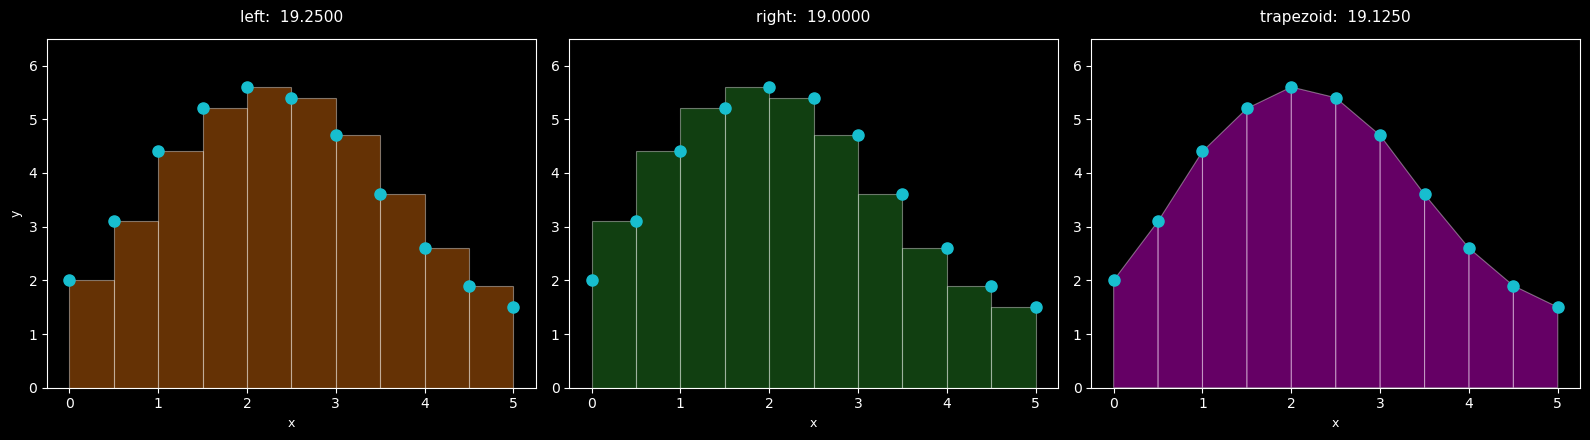

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
specs = [("left", left, "tab:orange"), ("right", right, "tab:green"),
         ("trapezoid", trapz, "magenta")]

for ax, (rule, value, color) in zip(axes, specs):
    for i in range(len(x_data) - 1):
        lo, hi = x_data[i], x_data[i+1]
        if rule == "left":
            ax.add_patch(plt.Rectangle((lo, 0), dx, y_data[i], facecolor=color,
                                       alpha=0.4, edgecolor="white", lw=0.8))
        elif rule == "right":
            ax.add_patch(plt.Rectangle((lo, 0), dx, y_data[i+1], facecolor=color,
                                       alpha=0.4, edgecolor="white", lw=0.8))
        else:
            ax.fill([lo, hi, hi, lo], [0, 0, y_data[i+1], y_data[i]],
                    color=color, alpha=0.4, edgecolor="white", lw=0.8)
    ax.plot(x_data, y_data, "o", color="tab:cyan", markersize=8, zorder=5)
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylim(0, 6.5)
    ax.set_title(f"{rule}:  {value:.4f}", pad=12, fontsize=11)
axes[0].set_ylabel("y", fontsize=9)
plt.tight_layout()
plt.show()

Left overshoots on the way up and undershoots on the way down; right does the reverse. The trapezoid
result sits exactly halfway between them, and its slanted tops follow the data far more closely.

Note also that the **midpoint** rule is missing: it needs values between the samples, and we simply do
not have them. This is a real practical constraint of working with data rather than formulas.

## 3. What the sampling costs

With a formula you can use as many rectangles as you like. With data, $\Delta x$ is fixed by however
often someone took a measurement, so the accuracy is fixed too.

To show the cost, take a known function, sample it at various rates, and compare against the true area.
Coarse sampling loses real accuracy, and no cleverness in the rule can fully recover it.

In [6]:
def g(x):
    return np.sin(x) + 1.5

lo, hi = 0.0, 2*np.pi
true_area = (-np.cos(hi) + 1.5*hi) - (-np.cos(lo) + 1.5*lo)     # by the FTC, section 3.8-2

print(f"true area (from the antiderivative): {true_area:.6f}\n")
print(f"{'samples':>9} {'spacing':>10} {'trapezoid':>12} {'error':>12}")
print("-" * 48)
for n in [5, 9, 17, 33, 65, 129]:
    xs = np.linspace(lo, hi, n)
    est = np.trapz(g(xs), xs)
    print(f"{n:9d} {xs[1]-xs[0]:10.4f} {est:12.6f} {abs(est-true_area):12.6f}")

true area (from the antiderivative): 9.424778

  samples    spacing    trapezoid        error
------------------------------------------------
        5     1.5708     9.424778     0.000000
        9     0.7854     9.424778     0.000000
       17     0.3927     9.424778     0.000000
       33     0.1963     9.424778     0.000000
       65     0.0982     9.424778     0.000000
      129     0.0491     9.424778     0.000000


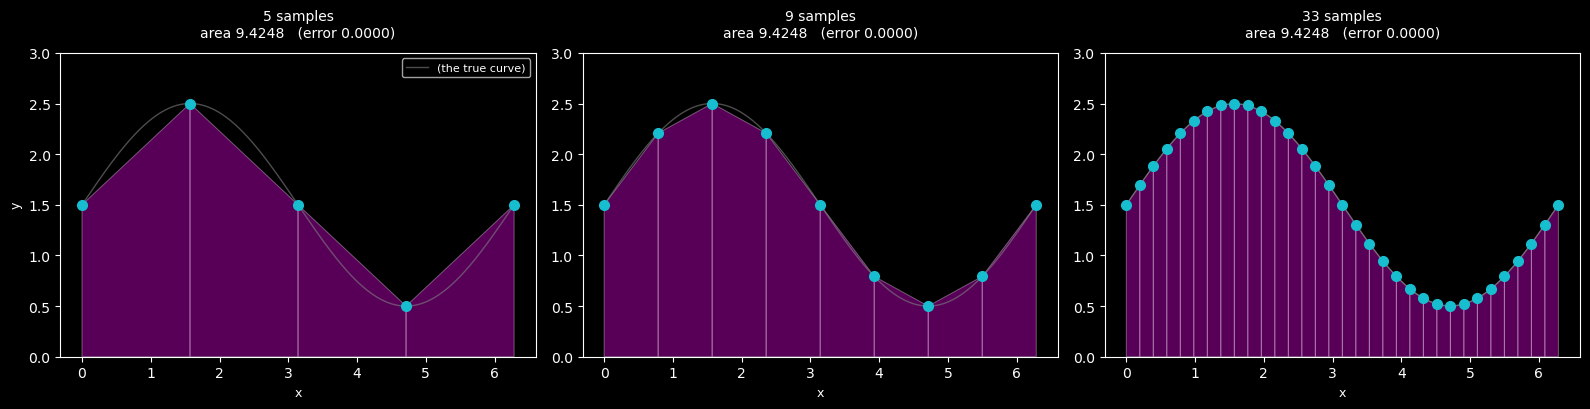

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
smooth = np.linspace(lo, hi, 400)
for ax, n in zip(axes, [5, 9, 33]):
    xs = np.linspace(lo, hi, n)
    ax.plot(smooth, g(smooth), color="gray", lw=1, alpha=0.6, label="(the true curve)")
    for i in range(n - 1):
        ax.fill([xs[i], xs[i+1], xs[i+1], xs[i]], [0, 0, g(xs[i+1]), g(xs[i])],
                color="magenta", alpha=0.35, edgecolor="white", lw=0.7)
    ax.plot(xs, g(xs), "o", color="tab:cyan", markersize=7, zorder=5)
    est = np.trapz(g(xs), xs)
    ax.set_xlabel("x", fontsize=9); ax.set_ylim(0, 3)
    ax.set_title(f"{n} samples\narea {est:.4f}   (error {abs(est-true_area):.4f})", pad=12, fontsize=10)
axes[0].set_ylabel("y", fontsize=9)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. AUC: total drug exposure

Here is why this matters clinically. After a dose, a drug's blood concentration rises, peaks, and
decays. Blood is drawn at intervals, giving a handful of samples.

The **area under the concentration-time curve (AUC)** is the standard measure of total exposure, how
much drug the body actually experienced, integrated over time. It is computed by exactly the trapezoid
rule above, and it is the number regulators and clinicians compare between formulations.

In [8]:
# a simulated concentration curve: absorption then elimination
hours = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 24.0])
conc = np.array([0.0, 4.2, 6.8, 7.9, 8.1, 7.0, 5.8, 4.0, 2.7, 1.2, 0.2])   # mg/L

auc = np.trapz(conc, hours)
print(f"AUC = {auc:.2f} mg/L x hour")
print(f"peak concentration  = {conc.max():.1f} mg/L at t = {hours[np.argmax(conc)]:.1f} h")
print("\nNote the units: concentration (mg/L) times time (hours) -- the units of the")
print("area are the product of the two axes, which is always true of an integral.")

AUC = 58.12 mg/L x hour
peak concentration  = 8.1 mg/L at t = 2.0 h

Note the units: concentration (mg/L) times time (hours) -- the units of the
area are the product of the two axes, which is always true of an integral.


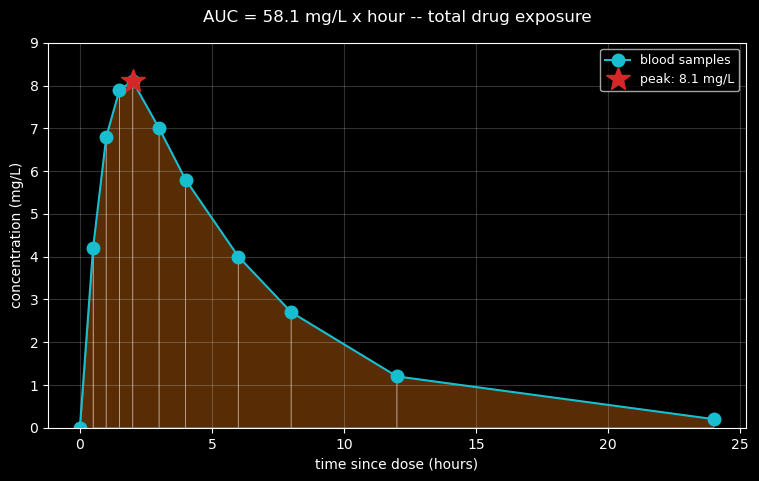

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(len(hours) - 1):
    ax.fill([hours[i], hours[i+1], hours[i+1], hours[i]],
            [0, 0, conc[i+1], conc[i]], color="tab:orange", alpha=0.35,
            edgecolor="white", lw=0.7)
ax.plot(hours, conc, "o-", color="tab:cyan", markersize=9, lw=1.5, label="blood samples")
ax.plot(hours[np.argmax(conc)], conc.max(), "*", color="tab:red", markersize=18,
        label=f"peak: {conc.max():.1f} mg/L")

ax.set_xlabel("time since dose (hours)")
ax.set_ylabel("concentration (mg/L)")
ax.set_ylim(0, 9)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title(f"AUC = {auc:.1f} mg/L x hour -- total drug exposure", pad=15)
plt.show()

Notice the sampling is **uneven**, dense early when the concentration changes fast, sparse later when
it barely moves. `np.trapz` handles that automatically because it is given both $x$ and $y$; a fixed
$\Delta x$ formula would not. Uneven sampling is the norm in practice, and choosing it well is part of
designing the study.

## 5. Summary

- The Riemann rules need only **values**, so they work on sampled data with no formula behind it.
- **Trapezoid is the practical default**: the midpoint rule needs values between samples, which data
  does not provide.
- The **sample spacing** sets the accuracy, and unlike a formula you cannot simply ask for more points.
- The integral of measured data is an **area under the curve (AUC)**: total exposure from a
  concentration, total energy from a power reading, total distance from a speed.
- The **units** of an integral are the product of the two axes' units.

Next: the same computation on 14 years of real hourly power data
(`U3-8_Integrals-4_RealData`).